# Biplane over Densities - Samples

In [1]:
try:
    import mat73
except ImportError:
    pass

from pathlib import Path
from typing import Sequence

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
import tifffile

In [2]:
path = "../../../"
path = Path(path).expanduser()
import sys

sys.path.insert(0, str(path))

In [3]:
import decode
import decode.neuralfitter.inference.functional as infer_func
print(decode.__file__)
log = decode.generic.logging.get_logger(__name__)

%config InlineBackend.figure_format='retina'

/data1/shah/miniconda3/envs/decode_uipsf/lib/python3.10/site-packages/torchmetrics/utilities/imports.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


/home/shahao/projects/DECODE-Plex/notebook/biplane/simulation/../../../decode/__init__.py


In [ ]:
# some paths and hardware settings
path_spline = "../../../calibration/Fig1c_2c-Pos0_240621_NC_BeadCal_BifocalPlane_Z_1_MMStack_Default.ome_3dcal.mat"
path_trafo = "../../../calibration/Fig1c_2c-Pos0_240621_NC_BeadCal_BifocalPlane_Z_1_MMStack_Default.ome_trafo.mat"

path_out = "../../../data/density/biplane"
path_out = Path(path_out).expanduser()

trafo_size_ref = 512
trafo_mirr_dim = 0

device = "cuda:0"

path_spline, path_trafo = Path(path_spline).expanduser(), Path(path_trafo).expanduser()

../../../data/density/biplane


In [5]:
xextent = (50.5, 205.5)
yextent = xextent
zextent = (-600., 600.)

img_shape = (256, 256)
px_size = (100, 100)  # fake, but doesn't matter
frame_extent = ((-0.5, img_shape[0] - 0.5), (-0.5, img_shape[1] - 0.5))

n_frames = 1000  # per step
em_min = 1e5
frame_min = 50
frame_max = 1000
n_steps = 16

psf_norm = [1., 1.] # biplane

density = torch.logspace(math.log10(0.03), math.log10(3.), n_steps)
area = 127**2 * 1e-6 * (xextent[1] - xextent[0]) * (yextent[1] - yextent[0])  # um^2
n_emitter = density * area

choric_mat = [1., 1.]

random_seed = 42  # emitters in the same n_frames / n_steps combination will be the same


In [6]:
# definition of scenarios

# product dimensions
em = pd.DataFrame({"n_emitter": n_emitter.tolist()})
# snr = pd.DataFrame({"snr": ["low", "medium", "high"]})
snr = pd.DataFrame({"snr": ["medium"]})

scen = pd.merge(em, snr, how="cross")

# add derived columns
scen["density"] = scen["n_emitter"] / area

scen["n_frames"] = em_min / scen["n_emitter"]
scen["n_frames"] = scen["n_frames"].apply(lambda x: int(min(max(x, frame_min), frame_max)))
scen.at[:, "phot_loc"] = scen["snr"].map({
    # "low": [1000., 1000.],
    "medium": 5000.,  # AF647, CF680
    # "high": [20000., 20000.],
})
scen["phot_scale"] = None
scen["phot_scale"] = scen["phot_loc"] / 4


scen.sort_values(["snr", "density"], inplace=True)
scen["index"] = np.arange(len(scen))
scen = scen.set_index(["snr", "index"])

# bg derived by other parameters
scen["bg"] = None
scen.at["medium", "bg"] = [[50., 50.]]

# dichoric
scen["choric"] = None
scen.loc[:, "choric"] = scen.loc[:, "choric"].apply(lambda _: choric_mat)
# scen.at["high", "choric"] = [[0.173, 0.06]]
# scen.at["medium", "choric"] = [[0.173, 0.019]]
# scen.at["low", "choric"] = [[0.173, 0.06]]

# lifetimes
scen["lifetime"] = None
scen.at["medium", "lifetime"] = 1.

# set up target filters
scen["phot_min"] = None
# scen.loc["high", "phot_min"] = 1000.
scen.loc["medium", "phot_min"] = 100.
# scen.loc["low", "phot_min"] = 50.

scen


n_emitter   density  n_frames  phot_loc  phot_scale  \
snr    index                                                          
medium 0        11.624977  0.030000      1000    5000.0      1250.0   
       1        15.802486  0.040781      1000    5000.0      1250.0   
       2        21.481211  0.055435      1000    5000.0      1250.0   
       3        29.200621  0.075357      1000    5000.0      1250.0   
       4        39.694050  0.102436      1000    5000.0      1250.0   
       5        53.958359  0.139248      1000    5000.0      1250.0   
       6        73.348648  0.189287      1000    5000.0      1250.0   
       7        99.706947  0.257309      1000    5000.0      1250.0   
       8       135.537292  0.349774       737    5000.0      1250.0   
       9       184.243484  0.475468       542    5000.0      1250.0   
       10      250.452545  0.646330       399    5000.0      1250.0   
       11      340.454254  0.878593       293    5000.0      1250.0   
       12      462.798676  1.194322       216    5000.0      1250.0   
       13      629.108337  1.623509       158    5000.0      1250.0   
       14      855.182434  2.206927       116    5000.0      1250.0   
       15     1162.497681  3.000000        86    5000.0      1250.0   

                        bg      choric lifetime phot_min  
snr    index                                              
medium 0      [50.0, 50.0]  [1.0, 1.0]      1.0    100.0  
       1      [50.0, 50.0]  [1.0, 1.0]      1.0    100.0  
       2      [50.0, 50.0]  [1.0, 1.0]      1.0    100.0  
       3      [50.0, 50.0]  [1.0, 1.0]      1.0    100.0  
       4      [50.0, 50.0]  [1.0, 1.0]      1.0    100.0  
       5      [50.0, 50.0]  [1.0, 1.0]      1.0    100.0  
       6      [50.0, 50.0]  [1.0, 1.0]      1.0    100.0  
       7      [50.0, 50.0]  [1.0, 1.0]      1.0    100.0  
       8      [50.0, 50.0]  [1.0, 1.0]      1.0    100.0  
       9      [50.0, 50.0]  [1.0, 1.0]      1.0    100.0  
       10     [50.0, 50.0]  [1.0, 1.0]      1.0    100.0  
       11     [50.0, 50.0]  [1.0, 1.0]      1.0    100.0  
       12     [50.0, 50.0]  [1.0, 1.0]      1.0    100.0  
       13     [50.0, 50.0]  [1.0, 1.0]      1.0    100.0  
       14     [50.0, 50.0]  [1.0, 1.0]      1.0    100.0  
       15     [50.0, 50.0]  [1.0, 1.0]      1.0    100.0

In [7]:
structure = decode.simulation.structures.RandomStructure(
    xextent, yextent, zextent
)

In [8]:
xextent_psf = ((-0.5, 255.5),) * 2
yextent_psf = xextent_psf
img_shape_psf = (img_shape,) * 2

psf = decode.io.psf.load_spline(
    path_spline,
    xextent=xextent_psf,
    yextent=yextent_psf,
    img_shape=img_shape_psf,
    device=device,
    norm=psf_norm,
    kwargs_static={"max_frame_chunk": 10000, "max_roi_chunk": 10000},
)

In [9]:
# offset = [-14, 0, 0]  # found out by cli tool in decode
offset = [47., -13., 0.]

trafo = decode.io.trafo.load_xyz_trafo(
    path_trafo,
    scale=1 / 1000.0,
    switch_xy=True,
    shift=(1.0, 1.0, 0.0),
    reference="trafo_inv_raw",
    device=device,
)
t_mirr = decode.simulation.trafo.pos.trafo.XYZMirrorAt.from_frame_flip(
    trafo_size_ref,
    trafo_mirr_dim,
    device=device,
)
t_mirr = decode.simulation.trafo.pos.trafo.XYZChanneledTransformation(
    t_mirr,
    ch=1,
)
trafo.append(t_mirr)
trafo_shift = decode.simulation.trafo.pos.trafo.XYZShiftTransformation(
    offset, device=device
)
trafo_shift = decode.simulation.trafo.pos.trafo.XYZChanneledTransformation(trafo_shift, 1)

# final trafo
trafo.append(trafo_shift)
trafo = trafo.to("cpu")
# trafo = decode.simulation.trafo.pos.trafo.XYZTransformationNoOp(n_channels=2)
trafo

2026-04-27 17:08:36 [info     ] Running experimental function `load_xyz_trafo` tested=True


XYZCompositTransformation([
    XYZShiftTransformation(tensor([1., 1., 0.]), cpu),
    XYZScaleTransformation(0.0010000000474974513, global),
    XYZTransformationGeneric(<function _coord_permute_smap at 0x7bea447435b0>, None, cpu, True),
    XYZTransformationMatrix(tensor([[[ 1.0000,  0.0000,  0.0000],
         [ 0.0000,  1.0000,  0.0000],
         [ 0.0000,  0.0000,  1.0000]],

        [[ 1.0016, -0.0362,  0.0020],
         [-0.0362, -1.0010,  0.0012],
         [ 0.0174,  0.5653,  1.0000]]])),
    XYZTransformationGeneric(<function _coord_permute_smap at 0x7bea447435b0>, None, cpu, True),
    XYZScaleTransformation(1000.0, global),
    XYZShiftTransformation(tensor([-1., -1., -0.]), cpu),
    XYZChanneledTransformation(XYZMirrorAt(axis=0, at=511, device=cpu), 1),
    XYZChanneledTransformation(XYZShiftTransformation(tensor([ 47., -13.,   0.]), cpu), 1)
])

In [10]:
cam = decode.simulation.camera.CameraPerfect(sensor_size=img_shape, device=device)
cam = [cam] * 2

choric = decode.simulation.trafo.photon.trafo.MultiChoricSplitter(choric_mat)

mic = decode.simulation.microscope.MicroscopeMultiChannel(
    psf=psf,
    noise=cam, # manually, because then we can batch
    frame_range=(0, n_frames),
    ch_range=(0, 2),
)

# Sample

In [11]:
# independents
scen_x = scen.copy()

scen_x["em"] = None
scen_x["em_ch"] = None
scen_x["bg_frame"] = None

torch.manual_seed(random_seed)

for ix, s in scen_x.iterrows():
    flux = (s["phot_loc"], s["phot_scale"])

    em = decode.simulation.sampler.EmitterSamplerBlinking(
        structure=structure,
        flux=(s["phot_loc"], s["phot_scale"]),
        em_num=s["n_emitter"],
        lifetime=s["lifetime"],
        frame_range=(0, s["n_frames"]),
        code=None,
        n_channels=1,
        xy_unit="px",
        px_size=px_size,
    ).sample()
    em.code = torch.zeros(len(em), dtype=torch.long)

    # filter out low photon ones
    em = em[em.phot.squeeze() >= s["phot_min"]]

    # choric_lin = torch.as_tensor(s["choric"])
    # choric_mat = decode.simulation.trafo.photon.utils.dual_from_ratio(choric_lin, 1)
    choric_mat = torch.as_tensor([s["choric"]])
    choric = decode.simulation.trafo.photon.trafo.MultiChoricSplitter(choric_mat)

    e_ch = em.clone()
    e_ch.phot = choric.forward(e_ch.phot.squeeze(), e_ch.code)
    e_ch.xyz = trafo.forward(e_ch.xyz)

    scen_x.at[ix, "em"] = em
    scen_x.at[ix, "em_ch"] = e_ch
    scen_x.at[ix, "bg_frame"] = [torch.ones(img_shape) * bg for bg in s["bg"]]


In [12]:
scen_y = pd.DataFrame(index=scen_x.index, columns=["frame"])

for ix, s in scen_x.iterrows():
    e_ch = s["em_ch"]
    bg_frame = s["bg_frame"]

    frames = mic.forward(e_ch, bg_frame, ix_low=0, ix_high=s["n_frames"])
    scen_y.at[ix, "frame"] = [ff.cpu() for ff in frames]

2026-04-27 17:09:22 [warning  ] Overwriting/Inferring code from phot instead of em.code.
2026-04-27 17:09:25 [warning  ] Overwriting/Inferring code from phot instead of em.code.
2026-04-27 17:09:30 [warning  ] Overwriting/Inferring code from phot instead of em.code.
2026-04-27 17:09:35 [warning  ] Overwriting/Inferring code from phot instead of em.code.
2026-04-27 17:09:38 [warning  ] Overwriting/Inferring code from phot instead of em.code.
2026-04-27 17:09:42 [warning  ] Overwriting/Inferring code from phot instead of em.code.
2026-04-27 17:09:50 [warning  ] Overwriting/Inferring code from phot instead of em.code.
2026-04-27 17:09:58 [warning  ] Overwriting/Inferring code from phot instead of em.code.
2026-04-27 17:10:05 [warning  ] Overwriting/Inferring code from phot instead of em.code.
2026-04-27 17:10:11 [warning  ] Overwriting/Inferring code from phot instead of em.code.
2026-04-27 17:10:15 [warning  ] Overwriting/Inferring code from phot instead of em.code.
2026-04-27 17:10:18 [

In [13]:
em = scen_x["em"].to_list()
em_ch = scen_x["em_ch"].to_list()
bg = scen_x["bg_frame"].to_list()

frames = scen_y["frame"].to_list()

# Export

In [ ]:
# make sure not to overwrite
path_save = path_out / f"n_frames-{n_frames}_n_steps-{n_steps}_seed-{random_seed}"
path_save.mkdir(exist_ok=True)

print(path_save)

../../../data/density/biplane
../../../data/density/biplane/n_frames-1000_n_steps-16_seed-42


In [29]:
# export scenarios
path_scen = path_save / "scenarios.pq"
scen.to_parquet(path_scen)

# export ground truth
gt = {
    "em": em,
    "em_ch": em_ch,
    "bg": bg,
}
path_gt = path_save / "gt.pt"
torch.save(gt, path_gt)

# export frames
path_frames = path_save / "frames.pt"
torch.save(frames, path_frames)

In [30]:
# export frames as tiffs per SNR, for this accumulate the frames per scenario and bookkeep the lower and upper index
scen_bulk = pd.DataFrame(index=scen.index)

# make sure to not have negative values
offset = 100

# bookkeep frame length of each scenario and infer the lower and upper index
frame_len = [len(f[0]) for f in frames]
scen_bulk["frame_len"] = frame_len
scen_bulk["ix_low"] = None


# per snr, infer the lower and upper index
aux_cumsum = scen_bulk.groupby("snr").apply(lambda x: x["frame_len"].cumsum())
if len(scen_bulk.index.get_level_values(0).unique()) == 1:
    aux_cumsum = aux_cumsum.T
else:
    aux_cumsum = aux_cumsum.droplevel(0)
scen_bulk["ix_high"] = aux_cumsum

# infer ix_low
scen_bulk["ix_low"] = scen_bulk["ix_high"].shift(1)
# per snr, fill the first ix_low with 0
ix = scen_bulk.groupby(level=0).head(1).index
scen_bulk.loc[ix, "ix_low"] = 0
scen_bulk["ix_low"] = scen_bulk["ix_low"].astype(int)

#infer path
scen_bulk["name"] = None
for s in scen_bulk.index.get_level_values(0).unique():
    scen_bulk.loc[s, "name"] = f"frames_snr-{s}_offset-{offset}_ome.tif"

# export scenarios for saving
path_scen_bulk = path_save / "scen_bulk.pq"
scen_bulk.to_parquet(path_scen_bulk)

scen_bulk

frame_len  ix_low  ix_high                                  name
snr    index                                                                  
medium 0           1000       0     1000  frames_snr-medium_offset-100_ome.tif
       1           1000    1000     2000  frames_snr-medium_offset-100_ome.tif
       2           1000    2000     3000  frames_snr-medium_offset-100_ome.tif
       3           1000    3000     4000  frames_snr-medium_offset-100_ome.tif
       4           1000    4000     5000  frames_snr-medium_offset-100_ome.tif
       5           1000    5000     6000  frames_snr-medium_offset-100_ome.tif
       6           1000    6000     7000  frames_snr-medium_offset-100_ome.tif
       7           1000    7000     8000  frames_snr-medium_offset-100_ome.tif
       8            737    8000     8737  frames_snr-medium_offset-100_ome.tif
       9            542    8737     9279  frames_snr-medium_offset-100_ome.tif
       10           399    9279     9678  frames_snr-medium_offset-100_ome.tif
       11           293    9678     9971  frames_snr-medium_offset-100_ome.tif
       12           216    9971    10187  frames_snr-medium_offset-100_ome.tif
       13           158   10187    10345  frames_snr-medium_offset-100_ome.tif
       14           116   10345    10461  frames_snr-medium_offset-100_ome.tif
       15            86   10461    10547  frames_snr-medium_offset-100_ome.tif

In [31]:
# frames_cat = [torch.cat([f[0], torch.flip(f[1], dims=[1])], dim=1) for f in frames] 
frames_cat = [torch.cat(f, dim=1) for f in frames]  # put channels next to each other
frames_cat[0].size()

torch.Size([1000, 512, 256])

In [32]:
# export all scenarios as tiff's (combined, such that we can fit faster)
# per frame, accumulate the frames and save

scen_save = scen_bulk.reset_index().set_index("name").sort_index()

for name in scen_save.index.unique():
    sub = scen_save.loc[name]

    # collect frames in sub_scenario
    f = torch.cat([frames_cat[i] for i in sub["index"].values], dim=0)
    f = f + offset
    path_tiff = path_save / name 
    tifffile.imwrite(path_tiff, f.long().numpy().astype(np.int32), ome=True)

# DEBUG AREA

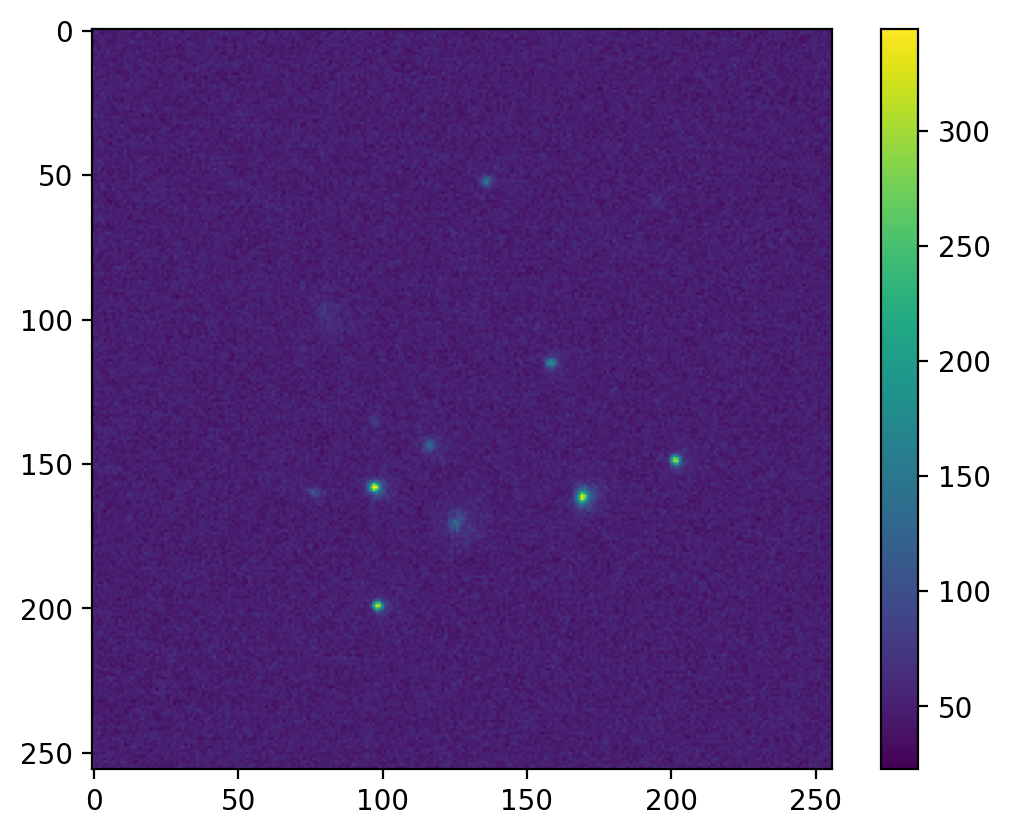

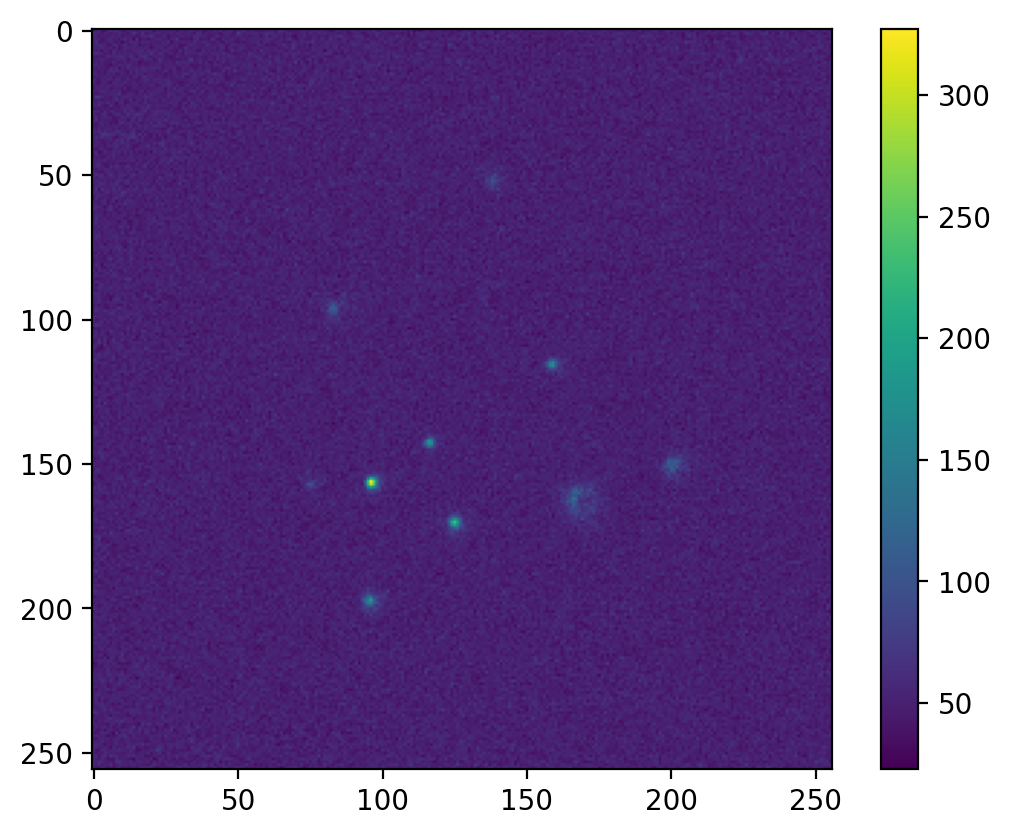

In [33]:
em = scen_x.iloc[0].em
em_ch = scen_x.iloc[0].em_ch

frames = scen_y.iloc[0].frame

f_ix = 42

em_f = em.iframe[42]
ff = [f[f_ix] for f in frames]

# decode.plot.PlotFrameCoord(frame=ff[0], pos_out=em_f.xyz_px).plot()
plt.imshow(ff[0])
plt.colorbar()
plt.show()
plt.imshow(ff[1])
# decode.plot.PlotFrameCoord(frame=ff[1], pos_out=em_f.xyz_px).plot()
plt.colorbar()